In [1]:
#https://arxiv.org/pdf/1609.03499

#based on audio predicter using hierarchichal approach ( see tree structure in fig. 3.

In [ ]:
####again starting from the class structure in L4. 

In [2]:
###set up data

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline


words = open('names.txt', 'r').read().splitlines()
print(words[:8], len(words))

# vocab of char mappings against integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos, vocab_size)


##Building dataset splits
block_size = 3 

def build_dataset(words):
    
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'] 32033
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'} 27
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [31]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])
##what we want (sort of)

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


In [205]:
###class implementation of the MLP with layer modules. 

class Linear:
    """
    torch.nn.linear (omitting devices (e.g. cuda) and dtype (e.g. float double). 
    """
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) /fan_in**0.5 #Kaiming 
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out +=  self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])  ### {} --> []

class BatchNorm1d:
    """
    torch.nn.batchnorm1d   with affine = True, track_running stats = true (device = cpu, dtype = float32). 
    """
    def __init__(self, dim, eps= 1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True #false for evaluation. 
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #buffers (trained with a running momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        #calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim, keepdim=True) #batch mean
            xvar = x.var(dim, keepdim = True, unbiased = True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta ###not in pytorch but helps us plot. 
        #update the training buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta] 

class Tanh:
    """
    torch.nn.Tanh
    """
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [26]:
torch.manual_seed(42);# for reproducibility ##instead of the generator, its simpler. 

In [46]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layaer of the MLP

C = torch.randn((vocab_size, n_embd))


##plan today is to improve the network structure
""" 
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size)
]
"""
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), 
    BatchNorm1d(n_hidden), 
    Tanh(),
    Linear(n_hidden, vocab_size), 
]

##classes make the layer stacking easy, its just a list called sequentially. 
#before batchnorm1d just omit it. e.g. Linear(n_hidden, n_hidden),Tanh(),
###he also does one version with Linear(bias = False)

#initparameters
with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1     #####this leads to the pink line outlier, but it stabalises. (used this when outpu layer was Linear)
    #layers[-1].gamma *= 0.1 ### if output layer is a Batchnorm, instead of weight. 
    # all other layers have gain applied.
    
#    for layer in layers[:-1]:
#        if isinstance(layer, Linear):
#            layer.weight *= 5/3 #Linear layers + tanh gain, replenishes output s.d. to same as input. - this matters less with batch normalization. 

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [48]:
# some optimization as alst time.
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batach, X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) #concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # after debugf would take out retin_graph >???
    for p in parameters:
        p.grad = None
        
    loss.backward() ####rewriting this in L5.

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay.
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    #if i >=20000:
    #    break

      0/ 200000: 3.3066
  10000/ 200000: 2.2293
  20000/ 200000: 1.9144
  30000/ 200000: 1.8224
  40000/ 200000: 2.1262
  50000/ 200000: 2.5607
  60000/ 200000: 2.0483
  70000/ 200000: 1.8803
  80000/ 200000: 2.0124
  90000/ 200000: 1.6901
 100000/ 200000: 2.2702
 110000/ 200000: 2.0404
 120000/ 200000: 1.9601
 130000/ 200000: 2.1027
 140000/ 200000: 1.7612
 150000/ 200000: 1.8920
 160000/ 200000: 2.2649
 170000/ 200000: 2.0211
 180000/ 200000: 2.2300
 190000/ 200000: 2.1459


layer 2 (      Tanh): mean -0.01, std 0.66, saturated: 12.47%


Text(0.5, 1.0, 'activation distribution')

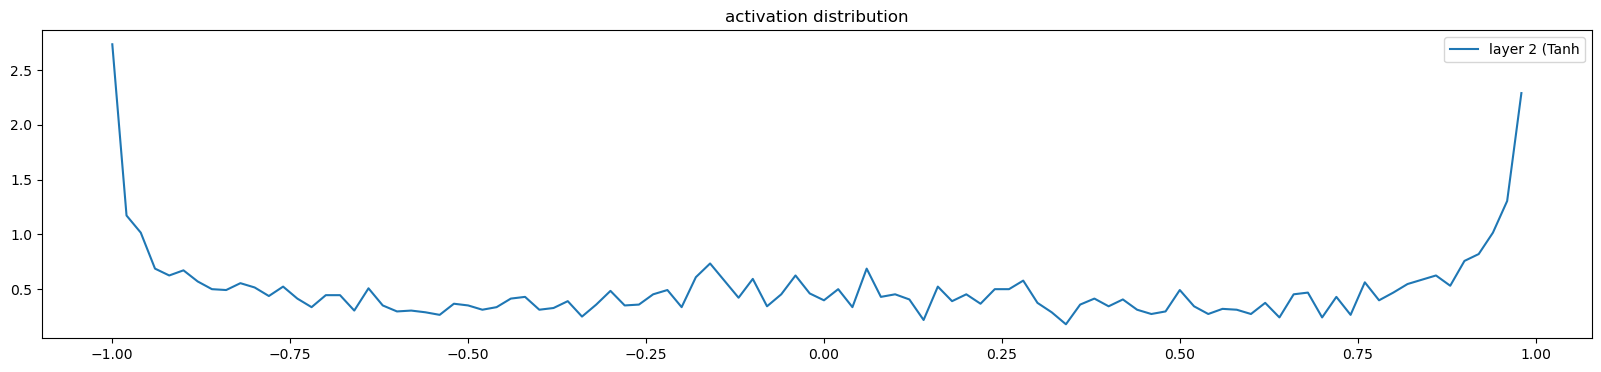

In [50]:
# visualise histograms

plt.figure(figsize = (20,4)) 
legends = []
for i, layer in enumerate(layers[:-1]): # excluding output layer.
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')
             

layer 2 (      Tanh): mean +0.000010, std 6.188304e-03


Text(0.5, 1.0, 'activation gradient distribution')

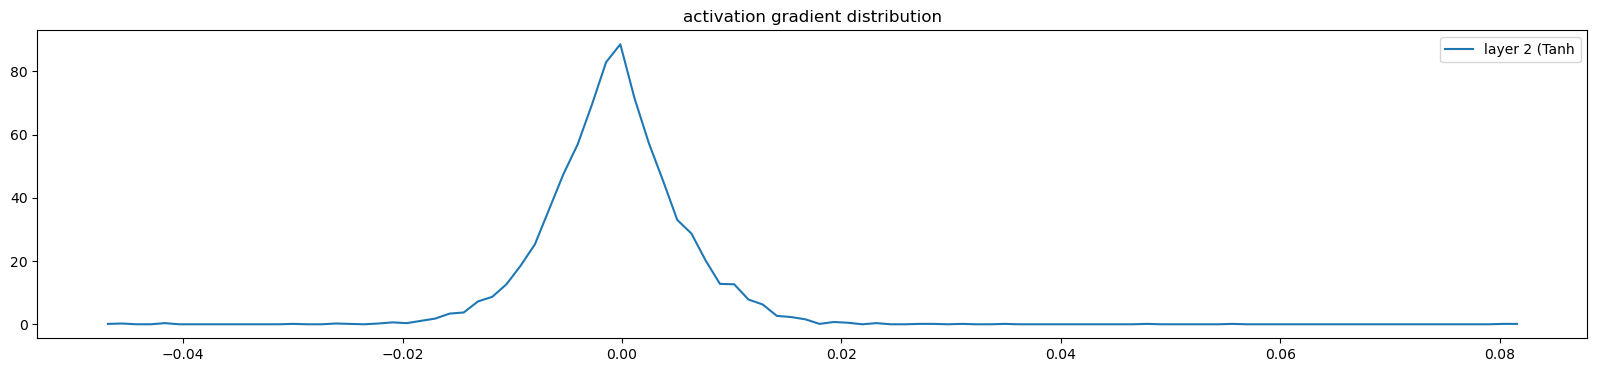

In [51]:
plt.figure(figsize = (20,4)) 
legends = []
for i, layer in enumerate(layers[:-1]): # excluding output layer.
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.744982e-02 | grad:data ratio 1.557164e-02
weight  (30, 200) | mean +0.000046 | std 1.205156e-02 | grad:data ratio 2.926399e-02
weight  (200, 27) | mean +0.000000 | std 1.935640e-02 | grad:data ratio 8.324941e-02


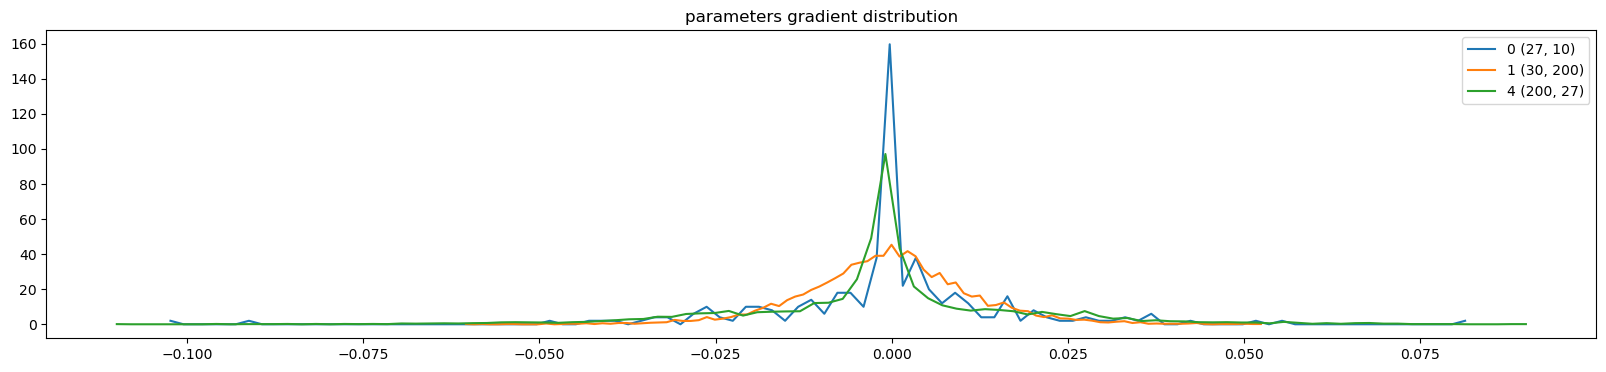

In [52]:
plt.figure(figsize = (20,4)) 
legends = []
for i,p in enumerate(parameters): 
    t = p.grad
    if p.ndim == 2:  #restricted to 2d weights of linear layer.
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('parameters gradient distribution');

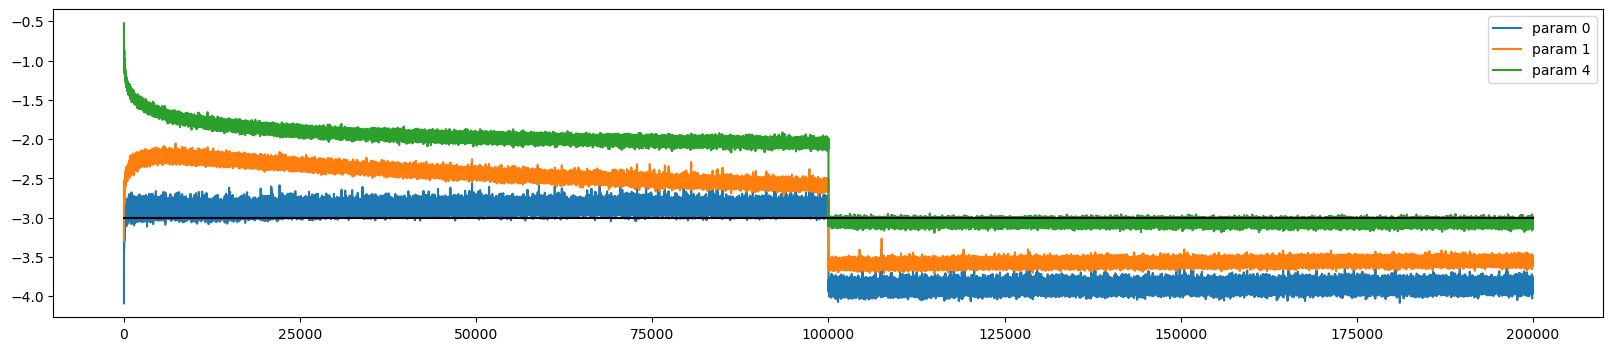

In [53]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3,-3], 'k') # these ratios should be ~1e-3, indicated on plot
plt.legend(legends);
###slow training will have values here 10,000 times smaller than the tensor size. 
#its near the black line that things are ok. 

In [54]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test' : (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # concat into (N, block_size, n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

# put layers into eval mode
for layer in layers:
    layer.training = False
    
split_loss('train')
split_loss('val')

train 2.0635993480682373
val 2.1075103282928467


In [55]:
#sample from the model
g = torch.Generator().manual_seed(2147483657)

for _ in range(20):
    out = []
    context = [0] * block_size # initialise with all...
    while True:
        # foward pass
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        x = emb.view(emb.shape[0], -1) # concatenate the vectors
        for layer in layers:
            x = layer(x) 
        logits = x
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples = 1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmah.
amille.
khi.
mili.
taty.
skanden.
jazonel.
deliah.
jareei.
ner.
kingchaiivia.
leggy.
ham.
jois.
quinn.
shon.
emi.
adbi.
wazell.
dearynix.


In [ ]:
##good not great. 

200000


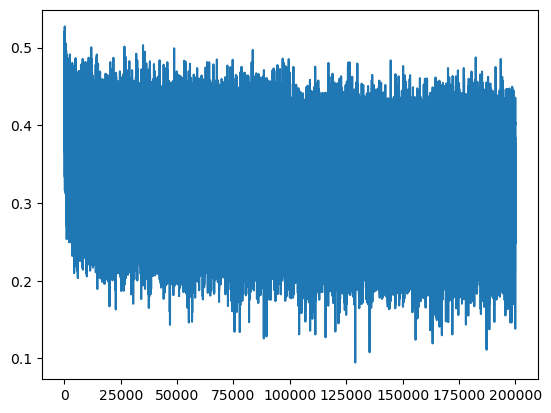

In [57]:
########starting L6 here. 
print(len(lossi))
plt.plot(lossi)  ###batches are too small.

In [58]:
# torch you can use -1 to ask torch to try and make it work
torch.arange(10).view(-1,5) #-1 = 2, in this example

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

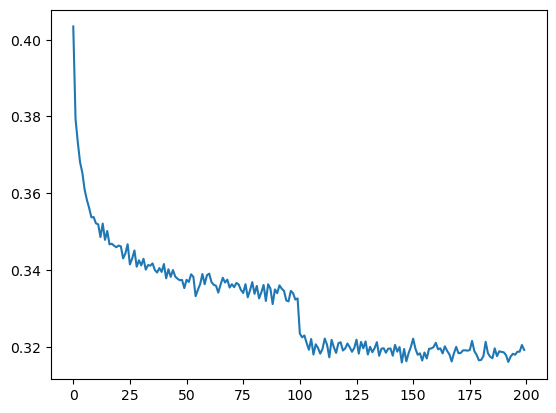

In [59]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [162]:
####adding new layers. 

class Embedding:
  """
  torch.nn.Embedding
  """
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

class Flatten:
    """
    torch.nn.Flatten 
    """
    def __call__(self, x):
        self.out = x.view(x.shape[0],-1)
        return self.out

    def parameters(self):
        return []

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:
  """
  departs from pytorch Flatten
  Flattens some n consecultive elements and puts them in the last dimension.
  """
  def __init__(self, n):
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []



In [71]:
n_embd = 10 
n_hidden = 200


layers = [
    Embedding(vocab_size, n_embd), #replaces C  & enables us to remove C from initialisation and the forward pass (only dealing with embedding layer now is much clearner). 
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), 
    BatchNorm1d(n_hidden), 
    Tanh(),
    Linear(n_hidden, vocab_size), 
]



with torch.no_grad():
    layers[-1].weight *= 0.1    

parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) 
for p in parameters:
    p.requires_grad = True

12097


In [74]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batach, X, Y

    # forward pass
    x = Xb
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward() ####rewriting this in L5.

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay.
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    #if i >=20000:
    #    break

      0/ 200000: 2.2312
  10000/ 200000: 2.2548
  20000/ 200000: 2.0284
  30000/ 200000: 2.6382
  40000/ 200000: 1.9610
  50000/ 200000: 1.9731
  60000/ 200000: 2.0704
  70000/ 200000: 1.8769
  80000/ 200000: 2.1716
  90000/ 200000: 1.9327
 100000/ 200000: 2.4154
 110000/ 200000: 2.2979
 120000/ 200000: 2.0002
 130000/ 200000: 2.1764
 140000/ 200000: 2.2511
 150000/ 200000: 1.9435
 160000/ 200000: 2.2359
 170000/ 200000: 2.3339
 180000/ 200000: 2.2547
 190000/ 200000: 2.2280


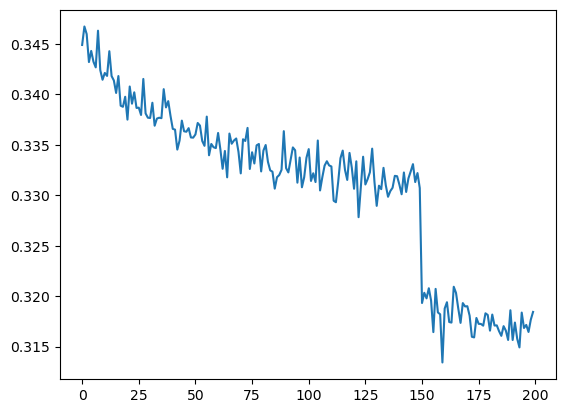

In [75]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [80]:
###################further pytorchifying.

In [79]:
### in pytorch, containers, let you maintain a list of layers. 
# -----------------------------------------------------------------------------------------------
class Sequential:
  """
  torch.nn.Sequential
  """
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [102]:
n_embd = 10 
n_hidden = 200


"""layers = [
    Embedding(vocab_size, n_embd), 
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), 
    BatchNorm1d(n_hidden), 
    Tanh(),
    Linear(n_hidden, vocab_size), 
]"""

model = Sequential([
    Embedding(vocab_size, n_embd), 
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), 
    BatchNorm1d(n_hidden), 
    Tanh(),
    Linear(n_hidden, vocab_size), 
])


with torch.no_grad():
    layers[-1].weight *= 0.1    

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) 
for p in parameters:
    p.requires_grad = True

12097


In [103]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batach, X, Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward() ####rewriting this in L5.

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay.
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    if i >=10000:
        break
    if (i == max_steps-1):
        plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))



      0/ 200000: 3.5083
  10000/ 200000: 2.0924


In [104]:
# put layers into eval mode
for layer in model.layers:
    layer.training = False

In [105]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test' : (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


    
split_loss('train')
split_loss('val')

train 2.252929925918579
val 2.2618045806884766


In [170]:
 ###careful. with batchnorm training validation mode
#if in training mode passing 1 number through will calulate a 1 number variance and divide by n-1 = 0 ... 

In [106]:
for _ in range(20):
    out = []
    context = [0] * block_size # initialise with all...
    while True:
        # foward pass
        logits = model(torch.tensor([context])) 
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples = 1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

man.
jareyah.
manseandelan.
shauni.
envelyn.
malin.
zaleianny.
jaid.
kayleir.
gar.
jaraceda.
addey.
tise.
feyce.
bianny.
kensta.
rsanfertenna.
avarmeds.
damseia.
keiz.


In [111]:
###now lets expand the network to pair combine each network (fig3 of the paper at the start)
#i.e. combine 2 letters, then 2 bigrams, then 2 quartgrams. (could continue. etc). 
# so we need a block size of 8 for us

##lazily scaling up the block size 3 to 8  improves it but we do want to change the network also. 

In [171]:
##Building dataset splits
block_size = 8

def build_dataset(words):
    
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

torch.Size([182424, 8]) torch.Size([182424])
torch.Size([22836, 8]) torch.Size([22836])
torch.Size([22886, 8]) torch.Size([22886])
........ --> n
.......n --> y
......ny --> r
.....nyr --> e
....nyre --> e
...nyree --> .
........ --> e
.......e --> d
......ed --> i
.....edi --> e
....edie --> .
........ --> c
.......c --> o
......co --> a
.....coa --> l
....coal --> s
...coals --> o
..coalso --> n
.coalson --> .
........ --> s


In [172]:
#consider the shapes. 
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)

torch.Size([4, 8])


In [173]:
model.layers[0].out.shape # embed output  -- "learns" a 10 element array per Xb element. 

torch.Size([4, 8, 10])

In [174]:
model.layers[1].out.shape #flatten output -- compresses the new embeddings onto long rows (concatenated). 

torch.Size([4, 80])

In [175]:
model.layers[2].out.shape # linear output -- 200 channels created by @ depending on the network params

torch.Size([4, 200])

In [176]:
(torch.randn(4,80) @ torch.randn(80, 200) + torch.randn(200)).shape ##current

torch.Size([4, 200])

In [177]:
(torch.randn(4,5,6,80) @ torch.randn(80, 200) + torch.randn(200)).shape
###adding dimentions doesn't change the matmul result (shape of the result), they are carried through broadcasting. 

torch.Size([4, 5, 6, 200])

In [178]:
(torch.randn(4,4,20) @ torch.randn(20, 200) + torch.randn(200)).shape  
##packing in the middle into 4 chunks instead of 1.
#(80/4 = 20)

torch.Size([4, 4, 200])

In [179]:
e = torch.randn(4,8,10)
explicit = torch.cat([e[:,::2,:], e[:,1::2,:]], dim=2)
##odds and evens but theres a shortcut in pytorch..

explicit.shape == e.view(4,4,20).shape ##

True

In [215]:
n_embd = 24 ##scaled up 24 ## prev 10
n_hidden = 200 #scaled up 200 ## #68 gives same parameters as before #200  

"""
model = Sequential([
    Embedding(vocab_size, n_embd), 
    FlattenConsecutive(8), ##Flatten() == FlattenConsecutive(8),
    Linear(n_embd * block_size, n_hidden, bias=False), 
    BatchNorm1d(n_hidden), 
    Tanh(),
    Linear(n_hidden, vocab_size), 
])"""

model = Sequential([
    Embedding(vocab_size, n_embd), 
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), 
])

#3 layers becaus the last one groups them also. 

with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) 
for p in parameters:
    p.requires_grad = True

176875


      0/ 200000: 3.4311
  10000/ 200000: 2.4580
  20000/ 200000: 1.9789
  30000/ 200000: 1.6126
  40000/ 200000: 2.0466
  50000/ 200000: 1.7801
  60000/ 200000: 2.0345
  70000/ 200000: 1.8512
  80000/ 200000: 1.8957
  90000/ 200000: 1.8377
 100000/ 200000: 2.2654
 110000/ 200000: 1.8849
 120000/ 200000: 1.8454
 130000/ 200000: 1.6067
 140000/ 200000: 2.3638
 150000/ 200000: 1.7223
 160000/ 200000: 1.9183
 170000/ 200000: 1.4716
 180000/ 200000: 1.9591
 190000/ 200000: 1.5751


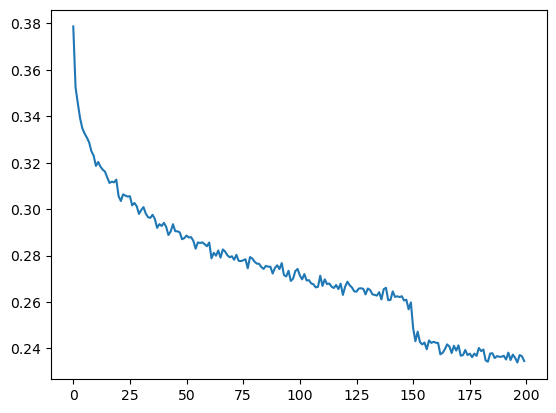

In [216]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batach, X, Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward() ####rewriting this in L5.

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay.
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    #if i >=10000:
    #    break
    if (i == max_steps-1):
        plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))



In [217]:
##printing layer shapes.
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 24)
FlattenConsecutive : (32, 4, 48)
Linear : (32, 4, 200)
BatchNorm1d : (32, 4, 200)
Tanh : (32, 4, 200)
FlattenConsecutive : (32, 2, 400)
Linear : (32, 2, 200)
BatchNorm1d : (32, 2, 200)
Tanh : (32, 2, 200)
FlattenConsecutive : (32, 400)
Linear : (32, 200)
BatchNorm1d : (32, 200)
Tanh : (32, 200)
Linear : (32, 27)


In [218]:
####ALWAYS check batchnorm, even if it runs. 
#currently it takes, 32,4,n_hidden. 

e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim =True) # 1,4,68
evar = e.var(0, keepdim=True) # 1,4,68
ehat = (e-emean) / torch.sqrt(evar + 1e-5) # 32, 4, 68
print(ehat.shape)

####we need to adapt it to average over 2d. 

emean = e.mean((0,1), keepdim =True) # 1,1,68
evar = e.var((0,1), keepdim=True) # 1,1,68
ehat = (e-emean) / torch.sqrt(evar + 1e-5) # 32, 4, 68
ehat.shape
#####needs to average over dimensions to put in form of 1d calculation.

###now adapting batchNorm1d to take Nd inputs.
###( addid if, elif introducing dim = 0 or (0,1)

torch.Size([32, 4, 68])


torch.Size([32, 4, 68])

In [219]:
for layer in model.layers:
    layer.training = False

def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test' : (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


    
split_loss('train')
split_loss('val')

print('')

for _ in range(20):
    out = []
    context = [0] * block_size # initialise with all...
    while True:
        # foward pass
        logits = model(torch.tensor([context])) 
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples = 1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

train 1.7004464864730835
val 1.9951155185699463

aisai.
andric.
anastasis.
atlana.
pinches.
tavun.
jakhio.
yaelyn.
lornov.
baxly.
zhania.
marielys.
leanna.
mattius.
lennyson.
rayen.
junezon.
aviann.
mautel.
jenika.


In [213]:
#### you should really tune the hyperparameters from now. 
##you should also look at validation loss alongside training loss. 

##the paper uses a gated linear layer that furthers this model (figure. 4) 

In [220]:
##Next time, can use convolutions so slide over input data. Linear layers become input filters. 

In [221]:
#we will also now use torch.nn directly rather than our own functions. 

In [222]:
##his dev method is keeping a jupyter notebook open for tests and then copying into the repo. 